**Implement LeNet from scratch and train and test model**

based on paper:
http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf

dataset for train and test model: MNIST

# **Import stuffs**

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras import layers, datasets, models
from tensorflow.keras.layers import Dense, Flatten, Dropout

import numpy as np
import matplotlib.pyplot as plt

# **Load Dataset**

In [4]:
dataset = datasets.mnist

In [5]:
# split dataset
(x_train,y_train),(x_test,y_test) = dataset.load_data()

In [6]:
# original dataset splits shape
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("\n")
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (60000, 28, 28)
y_train shape:  (60000,)


x_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


In [9]:
# Convert to float32 and normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Pad from 28x28 → 32x32
x_train = np.pad(x_train, ((0,0),(2,2),(2,2)), 'constant')
x_test = np.pad(x_test, ((0,0),(2,2),(2,2)), 'constant')

# Add channel dimension → (N,32,32,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [10]:
# correct dimention for splits samples shape
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("\n")
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (60000, 32, 32, 1)
y_train shape:  (60000,)


x_test shape:  (10000, 32, 32, 1)
y_test shape:  (10000,)


# **Implement model**

In [18]:
model = models.Sequential([
    layers.Conv2D(6, kernel_size=5, activation='tanh', input_shape=(32,32,1)),
    layers.AveragePooling2D(pool_size=(2, 2)),
    layers.Conv2D(16, kernel_size=5, activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2)),
    layers.Conv2D(120, kernel_size=5, activation='tanh'),
    layers.Flatten(),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# **Train model**

In [21]:
history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=40,
                    validation_split=0.1)

Epoch 1/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5096 - loss: 1.4094 - val_accuracy: 0.9052 - val_loss: 0.3211
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8909 - loss: 0.3598 - val_accuracy: 0.9288 - val_loss: 0.2317
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9164 - loss: 0.2748 - val_accuracy: 0.9433 - val_loss: 0.1918
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9288 - loss: 0.2327 - val_accuracy: 0.9523 - val_loss: 0.1643
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9395 - loss: 0.1983 - val_accuracy: 0.9587 - val_loss: 0.1429
Epoch 6/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9477 - loss: 0.1712 - val_accuracy: 0.9625 - val_loss: 0.1300
Epoch 7/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9544 - loss: 0.1505 - val_accuracy: 0.9682 - val_loss: 0.1182
Epoch 8/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9602 - loss: 0.1353 - val_accuracy: 0.

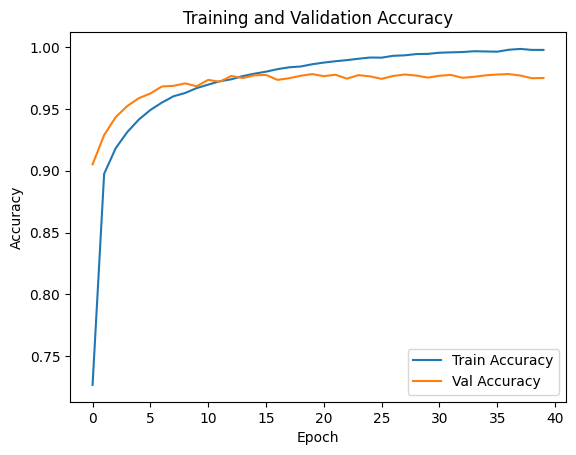

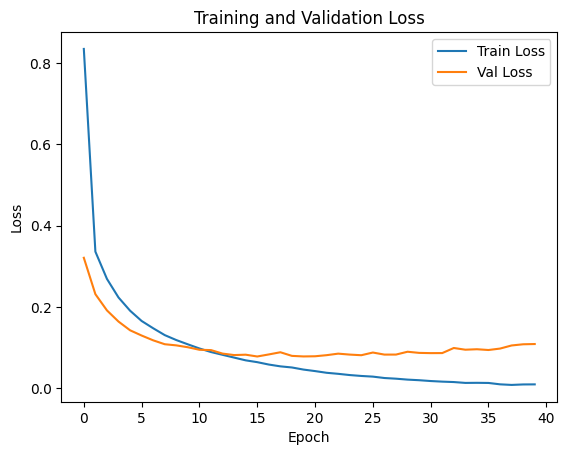

In [22]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


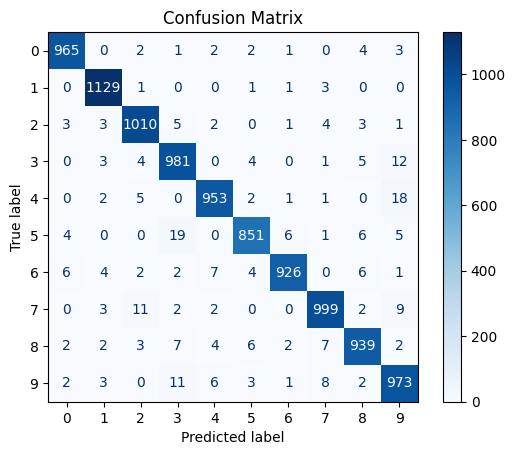

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred = model.predict(x_test).argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# **Test model**

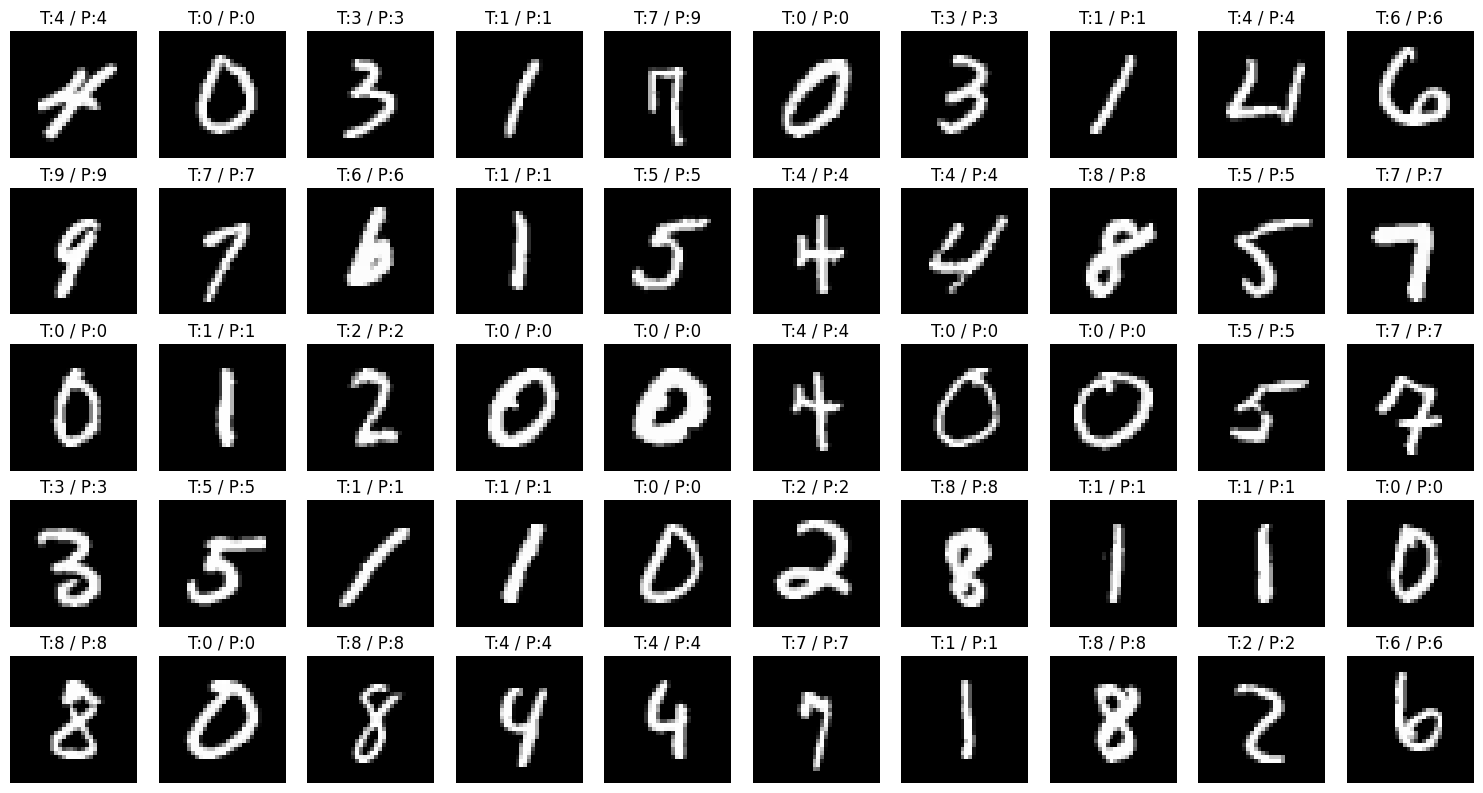

In [27]:
# Pick 50 random test samples
idx = np.random.choice(len(x_test), 50, replace=False)
images, labels, preds = x_test[idx], y_test[idx], y_pred[idx]

plt.figure(figsize=(15,8))
for i in range(50):
    plt.subplot(5,10,i+1)  # 5 rows, 10 columns = 50 slots
    plt.imshow(images[i].reshape(32,32), cmap='gray')
    plt.title(f"T:{labels[i]} / P:{preds[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
